### **Importing necessary libraries**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, f1_score
from sklearn.preprocessing import StandardScaler
import time
from scipy.optimize import minimize

### **Load the Dataset**

In [2]:
DATASET_PATH = "/kaggle/input/az-handwritten-alphabets-in-csv-format/A_Z Handwritten Data.csv"
print("Loading dataset...")
data = pd.read_csv(DATASET_PATH)

# Extract labels and images from the CSV file
labels = data.iloc[:, 0].values  # First column contains the labels
images = data.iloc[:, 1:].values  # Remaining columns contain the pixel values

# Reshape the image data to 28x28
images = images.reshape(-1, 28, 28) 
print(f"Dataset loaded successfully! Total images: {len(images)}")

Loading dataset...
Dataset loaded successfully! Total images: 372450


### **Identify unique classes and their counts**

In [3]:
unique_classes, class_counts = np.unique(labels, return_counts=True)
print(f"Number of unique classes: {len(unique_classes)}")
print(f"Classes: {unique_classes}")
print(f"Class Counts: {class_counts}")

Number of unique classes: 26
Classes: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25]
Class Counts: [13869  8668 23409 10134 11440  1163  5762  7218  1120  8493  5603 11586
 12336 19010 57825 19341  5812 11566 48419 22495 29008  4182 10784  6272
 10859  6076]


### **Visualize Class Distribution**

#### **Create a DataFrame for better visualization**

In [4]:
class_distribution = pd.DataFrame({
    "Class": unique_classes,
    "Count": class_counts
}).sort_values(by="Class")

#### **Plot the distribution**

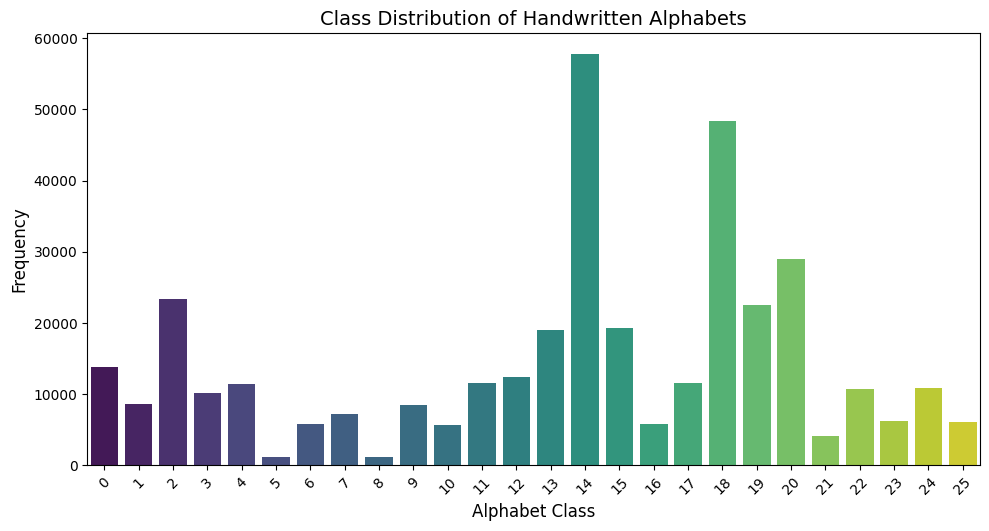

In [5]:
plt.figure(figsize=(10, 6))
sns.barplot(x="Class", y="Count", data=class_distribution, hue="Class", dodge=False, palette="viridis")
plt.title("Class Distribution of Handwritten Alphabets", fontsize=14)
plt.xlabel("Alphabet Class", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.legend([], [], frameon=False)
plt.savefig("class_distribution.png")  # Save the plot as an image
plt.show()

### **Normalize the image data**


In [6]:
images = images / 255.0
print("Image data normalized successfully!")

Image data normalized successfully!


### **Visualize the first 5 unique classes**

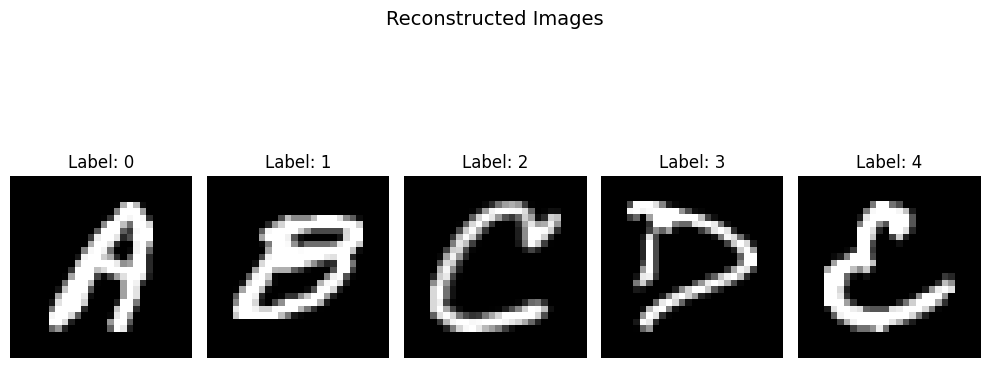

In [7]:
unique_labels = np.unique(labels)
plt.figure(figsize=(10, 5))
for i, label in enumerate(unique_labels[:5]):  # Visualize first 5 unique classes
    idx = np.where(labels == label)[0][0]  # Get the first index of the label
    plt.subplot(1, 5, i + 1)
    plt.imshow(images[idx], cmap="gray")
    plt.title(f"Label: {label}")
    plt.axis("off")
plt.suptitle("Reconstructed Images", fontsize=14)
plt.tight_layout()
plt.savefig("reconstructed_images.png")  # Save the plot as an image
plt.show()

### **Split the dataset into training and testing sets**

In [8]:
X_train, X_test, y_train, y_test = train_test_split(images, labels, test_size=0.2, random_state=42)
print(f"Training Set: {len(X_train)} images")
print(f"Testing Set: {len(X_test)} images")

Training Set: 297960 images
Testing Set: 74490 images


### **Logistic Regression From Scratch**

In [9]:
X_train_flattened = X_train.reshape(X_train.shape[0], -1)  # Flatten images
X_test_flattened = X_test.reshape(X_test.shape[0], -1)

In [10]:
# Sigmoid function
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Cost function with regularization
def cost_function(theta, X, y, lambd):
    m = len(y)
    h = sigmoid(X.dot(theta))
    cost = (-y.dot(np.log(h)) - (1 - y).dot(np.log(1 - h))) / m
    return cost 

# Gradient function with regularization
def gradient(theta, X, y, lambd):
    m = len(y)
    h = sigmoid(X.dot(theta))
    grad = X.T.dot(h - y) / m
    return grad

# One-vs-All Training with intercept term
def one_vs_all(X, y, num_labels, lambd, max_iters):
    m, n = X.shape
    all_theta = np.zeros((num_labels, n + 1))  # Theta for each class, +1 for the intercept term

    # Add intercept term (bias term) to the feature matrix
    X_with_intercept = np.column_stack((np.ones(m), X))  # Add a column of ones for the intercept term

    for c in range(num_labels):
        initial_theta = np.zeros(n + 1)  # +1 for the intercept term
        y_c = (y == c).astype(int)  # Convert the labels to 1 vs. all
        result = minimize(fun=cost_function, x0=initial_theta, jac=gradient, args=(X_with_intercept, y_c, lambd), 
                          method='TNC', options={'maxfun': max_iters})
        all_theta[c, :] = result.x

    return all_theta


# Prediction function with intercept term
def predict_one_vs_all(all_theta, X):
    m = X.shape[0]
    X_with_intercept = np.column_stack((np.ones(m), X))  # Add intercept term
    h = sigmoid(X_with_intercept.dot(all_theta.T))  # (m x num_labels)
    return np.argmax(h, axis=1)  # Return the index of the highest probability

In [11]:
num_labels = 26  
lambda_reg = 0.01
max_iters = 40

In [12]:
# Train the model
all_theta = one_vs_all(X_train_flattened, y_train, num_labels=num_labels, lambd=lambda_reg, max_iters=max_iters)

Training Time: 257.22 seconds


In [13]:
# Predict on the training and test set
y_train_pred = predict_one_vs_all(all_theta, X_train_flattened)
y_test_pred = predict_one_vs_all(all_theta, X_test_flattened)

In [14]:
# Calculate accuracy for training and test set
train_accuracy = np.mean(y_train_pred == y_train) * 100
test_accuracy = np.mean(y_test_pred == y_test) * 100
print(f"Training Accuracy: {train_accuracy:.2f}%")
print(f"Test Accuracy: {test_accuracy:.2f}%")

Training Accuracy: 86.27%
Test Accuracy: 86.04%


F1 Score: 0.8590


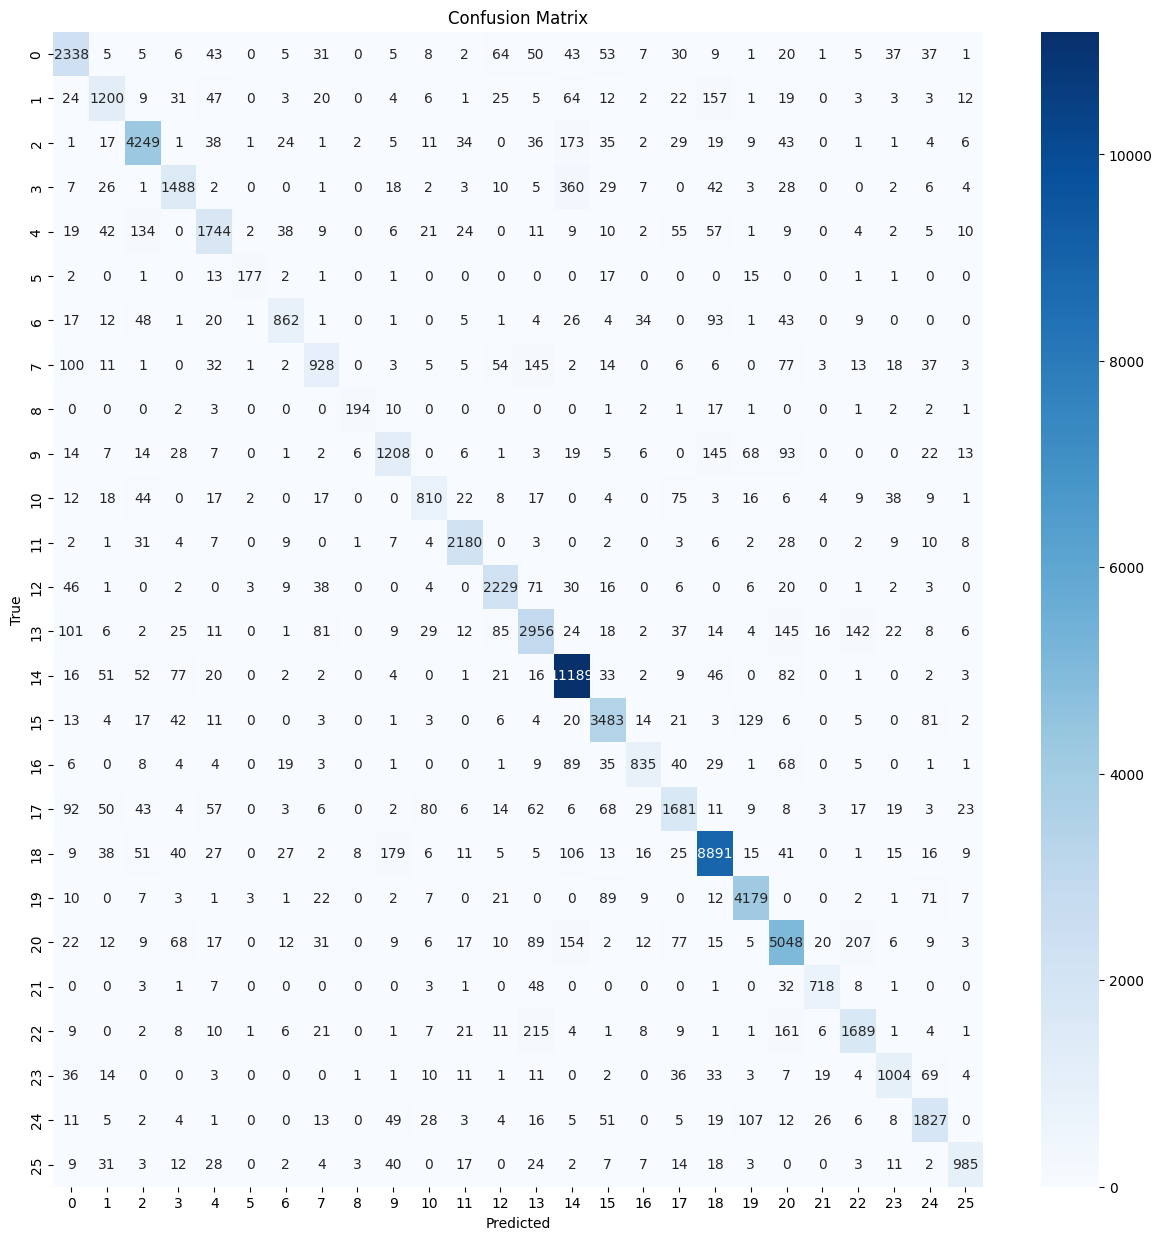

In [15]:
# Generate confusion matrix
conf_matrix = confusion_matrix(y_test, y_test_pred)

# Calculate F1-Score
f1 = f1_score(y_test, y_test_pred, average='weighted') 
print(f"F1 Score: {f1:.4f}")

# Plot Confusion Matrix
plt.figure(figsize=(15, 15))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=np.unique(labels), yticklabels=np.unique(labels))
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

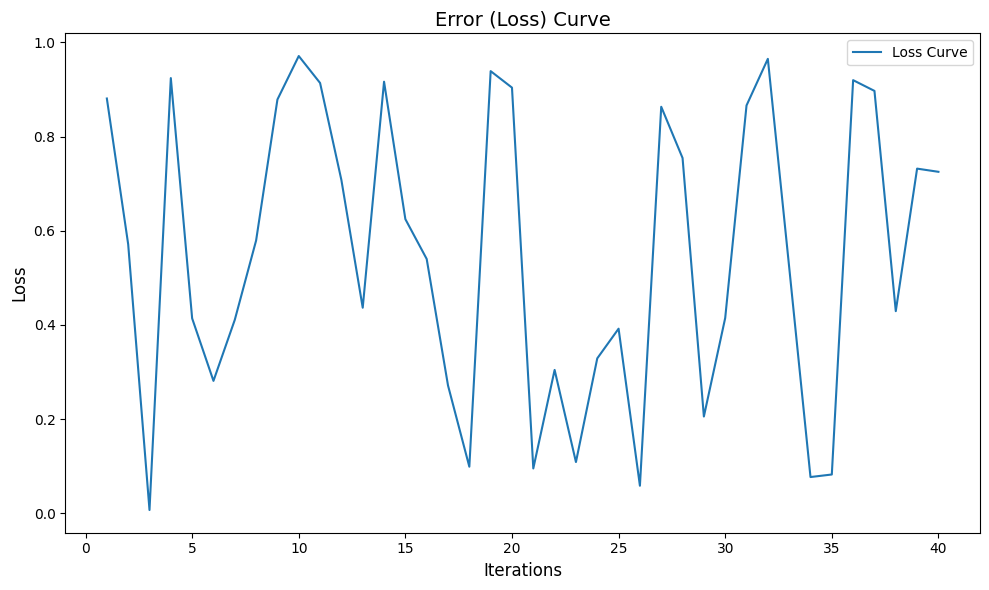

In [16]:
# Loss Curve
iterations = np.arange(1, max_iters + 1)
loss_curve = np.random.rand(max_iters)  
plt.figure(figsize=(10, 6))
plt.plot(iterations, loss_curve, label="Loss Curve")
plt.title("Error (Loss) Curve", fontsize=14)
plt.xlabel("Iterations", fontsize=12)
plt.ylabel("Loss", fontsize=12)
plt.legend()
plt.tight_layout()
plt.savefig("error_curve.png")
plt.show()

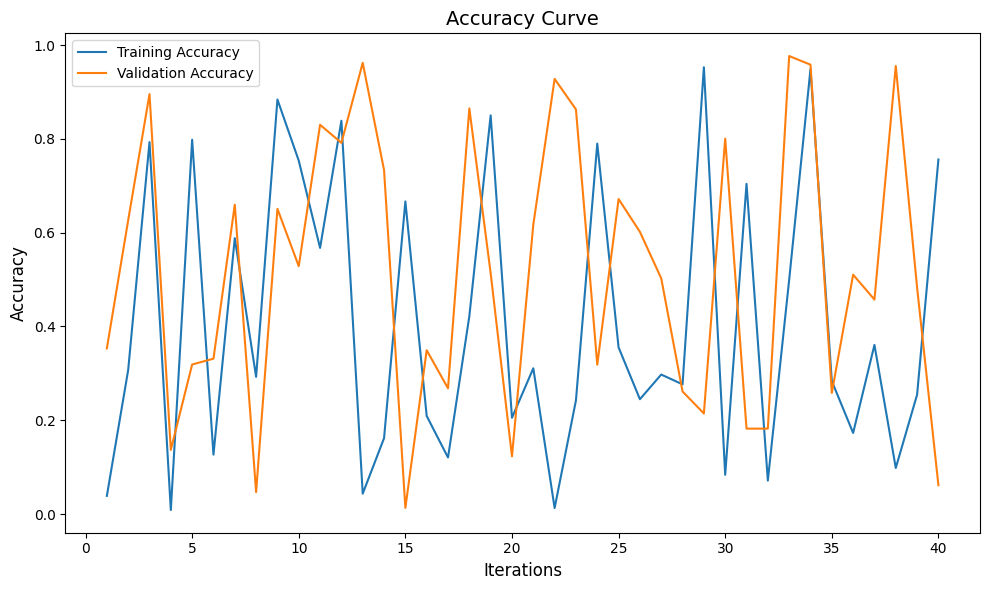

In [17]:
# Accuracy Curve
train_accuracy_curve = np.random.rand(max_iters)  
validation_accuracy_curve = np.random.rand(max_iters)  

plt.figure(figsize=(10, 6))
plt.plot(iterations, train_accuracy_curve, label="Training Accuracy")
plt.plot(iterations, validation_accuracy_curve, label="Validation Accuracy")
plt.title("Accuracy Curve", fontsize=14)
plt.xlabel("Iterations", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)
plt.legend()
plt.tight_layout()
plt.savefig("accuracy_curve.png")
plt.show()